## Лабораторная работа 8


№1 (3 балла)
Выполните задания из файла https://cloud.mail.ru/public/DGCu/Kw2Q4xGwd. Данные можно
взять здесь https://cloud.mail.ru/public/CiBD/PEaCv9DyD.

### Важность признаков


1. Загрузите выборку из файла titanic.csv с помощью пакета Pandas.

In [461]:
import pandas as pd

df = pd.read_csv('titanic.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


2. Оставьте в выборке четыре признака: класс пассажира (Pclass), цену билета (Fare), возраст пассажира (Age) и его пол (Sex).

In [462]:
filtered_df = df[['Pclass', 'Fare', 'Age', 'Sex', 'Survived']]
filtered_df

,Pclass,Fare,Age,Sex,Survived
0,3,7.2500,22.0,male,0
1,1,71.2833,38.0,female,1
2,3,7.9250,26.0,female,1
3,1,53.1000,35.0,female,1
4,3,8.0500,35.0,male,0
...,...,...,...,...,...
886,2,13.0000,27.0,male,0
887,1,30.0000,19.0,female,1
888,3,23.4500,NaN,female,0
889,1,30.0000,26.0,male,1


3. Обратите внимание, что признак Sex имеет строковые значения

In [463]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Fare      891 non-null    float64
 2   Age       714 non-null    float64
 3   Sex       891 non-null    object 
 4   Survived  891 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 34.9+ KB


In [464]:
filtered_df = pd.get_dummies(filtered_df, columns=['Sex'], drop_first=True)

In [465]:
filtered_df

,Pclass,Fare,Age,Survived,Sex_male
0,3,7.2500,22.0,0,True
1,1,71.2833,38.0,1,False
2,3,7.9250,26.0,1,False
3,1,53.1000,35.0,1,False
4,3,8.0500,35.0,0,True
...,...,...,...,...,...
886,2,13.0000,27.0,0,True
887,1,30.0000,19.0,1,False
888,3,23.4500,NaN,0,False
889,1,30.0000,26.0,1,True


4. Выделите целевую переменную — она записана в столбце Survived

In [466]:
target = filtered_df['Survived']
target

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

5. В данных есть пропущенные значения — например, для некоторых
пассажиров неизвестен их возраст. Такие записи при чтении их в
pandas принимают значение nan. Найдите все объекты, у которых
есть пропущенные признаки, и удалите их из выборки.


In [467]:
filtered_df.isna().sum()

Pclass        0
Fare          0
Age         177
Survived      0
Sex_male      0
dtype: int64

In [468]:
filtered_df = filtered_df.dropna()
filtered_df

,Pclass,Fare,Age,Survived,Sex_male
0,3,7.2500,22.0,0,True
1,1,71.2833,38.0,1,False
2,3,7.9250,26.0,1,False
3,1,53.1000,35.0,1,False
4,3,8.0500,35.0,0,True
...,...,...,...,...,...
885,3,29.1250,39.0,0,False
886,2,13.0000,27.0,0,True
887,1,30.0000,19.0,1,False
889,1,30.0000,26.0,1,True


In [469]:
target = filtered_df['Survived']
target

0      0
1      1
2      1
3      1
4      0
      ..
885    0
886    0
887    1
889    1
890    0
Name: Survived, Length: 714, dtype: int64

In [470]:
filtered_df.isna().sum()
filtered_df = filtered_df.drop(columns=['Survived'])

6. Обучите решающее дерево с параметром random_state=241 и остальными параметрами по умолчанию.


In [471]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X = filtered_df
y = target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
clf = DecisionTreeClassifier(random_state=241)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели: {accuracy:.4f}")

Точность модели: 0.7256


7. Вычислите важности признаков и найдите два признака с наибольшей важностью. Их названия будут ответами для данной задачи
(в качестве ответа укажите названия признаков через запятую без
пробелов).

In [472]:
filtered_df.shape

(714, 4)

In [473]:
target.shape

(714,)

In [474]:
importances = pd.Series(clf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)

Sex_male    0.320951
Age         0.282899
Fare        0.265846
Pclass      0.130305
dtype: float64

№2 (3 балла)
Построить дерево решений, определяющее наличие сахарного диабета у женщин. Данные
возьмите отсюда https://cloud.mail.ru/public/XD8U/pgDYnHrjY.

Данные содержат следующие характеристики:
1. Pregnancies – число случаев беременности
2. Glucose – концентрация глюкозы в крови
3. BloodPressure – артериальное диастолическое давление (мм рт. ст.)
4. SkinThickness – толщина кожной складки трехглавой мышцы (мм)
5. Insulin – 2-х часовой сывороточный инсулин
6. BMI – индекс массы тела
7. DiabetesPedigreeFunction – числовой параметр наследственности диабета
8. Age – возраст
Outcome – целевая переменная: 1 – наличие заболевания, 0 – отсутствие

1. Загрузите данные в DataFrame с помощью функции read_csv библиотеки pandas.


In [475]:
df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Unnamed: 9
0,6,148,72,35,0,"33,6","0,627",50,1,NaN
1,1,85,66,29,0,"26,6","0,351",31,0,NaN
2,8,183,64,0,0,"23,3","0,672",32,1,NaN
3,1,89,66,23,94,"28,1","0,167",21,0,NaN
4,0,137,40,35,168,"43,1","2,288",33,1,NaN
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,"32,9","0,171",63,0,NaN
764,2,122,70,27,0,"36,8","0,34",27,0,NaN
765,5,121,72,23,112,"26,2","0,245",30,0,NaN
766,1,126,60,0,0,"30,1","0,349",47,1,NaN


In [476]:
df.isna().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
Unnamed: 9                  768
dtype: int64

In [477]:
df = df.dropna(axis=1)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,"33,6","0,627",50,1
1,1,85,66,29,0,"26,6","0,351",31,0
2,8,183,64,0,0,"23,3","0,672",32,1
3,1,89,66,23,94,"28,1","0,167",21,0
4,0,137,40,35,168,"43,1","2,288",33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,"32,9","0,171",63,0
764,2,122,70,27,0,"36,8","0,34",27,0
765,5,121,72,23,112,"26,2","0,245",30,0
766,1,126,60,0,0,"30,1","0,349",47,1


In [478]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [479]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Pregnancies               768 non-null    int64 
 1   Glucose                   768 non-null    int64 
 2   BloodPressure             768 non-null    int64 
 3   SkinThickness             768 non-null    int64 
 4   Insulin                   768 non-null    int64 
 5   BMI                       768 non-null    object
 6   DiabetesPedigreeFunction  768 non-null    object
 7   Age                       768 non-null    int64 
 8   Outcome                   768 non-null    int64 
dtypes: int64(7), object(2)
memory usage: 54.1+ KB


In [480]:
df['BMI'] = df['BMI'].str.replace(',', '.').astype(float)
df['DiabetesPedigreeFunction'] = df['DiabetesPedigreeFunction'].str.replace(',', '.').astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


C:\Users\danil\AppData\Local\Temp\ipykernel_12812\806060780.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['BMI'] = df['BMI'].str.replace(',', '.').astype(float)
C:\Users\danil\AppData\Local\Temp\ipykernel_12812\806060780.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DiabetesPedigreeFunction'] = df['DiabetesPedigreeFunction'].str.replace(',', '.').astype(float)


2. Разделите данные на обучающую и тестовую выборки с помощью функции
train_test_split.

In [481]:
X = df.drop(columns = 'Outcome')
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=241)

3. Постройте дерево решений с помощью класса DecisionTreeClassifier.

In [482]:
clf = DecisionTreeClassifier(random_state=241)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

4. Оцените качество модели с помощью функции classification_report.


In [483]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.76      0.75       138
           1       0.62      0.59      0.61        93

    accuracy                           0.69       231
   macro avg       0.68      0.68      0.68       231
weighted avg       0.69      0.69      0.69       231



5. Подберите оптимальное значение гиперпараметра max_depth с помощью поиска по
сетке (класс GridSearchCV).

In [484]:
from sklearn.model_selection import GridSearchCV

parameters = {'max_depth':[2, 5, 10, 20, 100, 1000]}
dtc = DecisionTreeClassifier()
grid = GridSearchCV(dtc, parameters)
grid.fit(X_train, y_train)

# Вывод лучших параметров и результатов
print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучшая точность при кросс-валидации: {grid.best_score_:.4f}")

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test,y_pred_best))

Лучшие параметры: {'max_depth': 2}
Лучшая точность при кросс-валидации: 0.7560
              precision    recall  f1-score   support

           0       0.73      0.86      0.79       138
           1       0.71      0.54      0.61        93

    accuracy                           0.73       231
   macro avg       0.72      0.70      0.70       231
weighted avg       0.73      0.73      0.72       231



№3 (3 балла)
Выполните задания из файла https://cloud.mail.ru/public/2Btw/56cT2htNd. Данные можно
взять здесь https://cloud.mail.ru/public/mMAE/P3SZLgJWQ.

### Практическое задание №1.6.6


Для выполнения практического задания будем использовать файл
«winequality-red.csv», содержащий результаты физико-химических тестов
красного вина.
Источник: https://www.kaggle.com/uciml/red-wine-quality-cortez-et-al-2009.

Задача: построить модель случайного леса, определяющую хорошее вино
или плохое на основе результатов физико-химических тестов.
Входные переменные (признаки):
* • fixed acidity – фиксированная кислотность
* • volatile acidity – летучая кислотность
* • citric acid – содержание лимонной кислоты
* • residual sugar – остаточный сахар
* • chlorides – хлориды
* • free sulfur dioxide – свободный диоксид серы
* • total sulfur dioxide – общий диоксид серы
* • density – плотность
* • pH
* • sulphates – сульфаты
* • alcohol – спирт

Целевая переменная – quality (качество): 0 – плохое вино, 1 – хорошее вино.

1. Загрузите набор данных из файла «winequality-red.csv» в DataFrame.

In [485]:
df = pd.read_csv('winequality-red.csv' , decimal=",")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   fixed acidity         1599 non-null   object
 1   volatile acidity      1599 non-null   object
 2   citric acid           1599 non-null   object
 3   residual sugar        1599 non-null   object
 4   chlorides             1599 non-null   object
 5   free sulfur dioxide   1599 non-null   object
 6   total sulfur dioxide  1599 non-null   object
 7   density               1599 non-null   object
 8   pH                    1599 non-null   object
 9   sulphates             1599 non-null   object
 10  alcohol               1599 non-null   object
 11  quality               1599 non-null   int64 
dtypes: int64(1), object(11)
memory usage: 150.0+ KB


2. Обучите модель случайного леса (RandomForestClassifier).


In [486]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = df.drop(columns = 'quality')
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=241)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

3. Оцените качество модели. Метрики для оценки качества выберите
самостоятельно.

In [487]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Accuracy: 0.6833333333333333
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        15
           5       0.74      0.81      0.78       208
           6       0.63      0.70      0.66       190
           7       0.63      0.44      0.52        59
           8       0.00      0.00      0.00         6

    accuracy                           0.68       480
   macro avg       0.33      0.33      0.33       480
weighted avg       0.65      0.68      0.66       480



C:\Users\danil\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\danil\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\danil\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


4. Оцените информативность признаков с помощью атрибута
feature_importances_.

In [488]:
importances = pd.Series(clf.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

alcohol                 0.143314
sulphates               0.116388
total sulfur dioxide    0.107958
volatile acidity        0.103674
density                 0.090444
chlorides               0.080126
fixed acidity           0.074941
citric acid             0.074708
pH                      0.072759
residual sugar          0.070916
free sulfur dioxide     0.064769
dtype: float64


4. Поимпровизируйте с этими данными. Попробуйте построить другие модели
(на ваш выбор). Также, можно попробовать изменить значения
гиперпараметров моделей и посмотреть, как изменится результат.

In [489]:
param_grid = {
    'n_estimators': [100, 200],          # количество деревьев
    'max_depth': [None, 10, 20],          # глубина
    'min_samples_split': [2, 5],          # минимум для сплита
    'min_samples_leaf': [1, 2],            # минимум объектов в листе
    'max_features': ['sqrt'],   # выбор признаков
    'bootstrap': [True]                # бутстрап выборки
}

# Поиск лучших параметров
grid_search = GridSearchCV(
estimator=clf,
param_grid=param_grid,
cv=5,
scoring='accuracy',
n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

best_clf = grid_search.best_estimator_

y_pred = grid_search.best_estimator_.predict(X_test)
print("\nClassification report:\n", classification_report(y_test, y_pred))

{'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Classification report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        15
           5       0.75      0.81      0.78       208
           6       0.62      0.67      0.64       190
           7       0.55      0.44      0.49        59
           8       0.00      0.00      0.00         6

    accuracy                           0.67       480
   macro avg       0.32      0.32      0.32       480
weighted avg       0.64      0.67      0.65       480



C:\Users\danil\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\danil\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\danil\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [490]:
clf = DecisionTreeClassifier(random_state=241)
clf.fit(X_train, y_train)

y_pred_dt = clf.predict(X_test)
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.07      0.07      0.07        15
           5       0.70      0.65      0.68       208
           6       0.61      0.65      0.63       190
           7       0.47      0.54      0.50        59
           8       0.00      0.00      0.00         6

    accuracy                           0.61       480
   macro avg       0.31      0.32      0.31       480
weighted avg       0.61      0.61      0.61       480



C:\Users\danil\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\danil\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\danil\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


У дерева решений точность меньше(0.75), чем у случайного леса(0.82)

№4 (3 балла)
Выполните задания из файла https://cloud.mail.ru/public/nbue/PCozBiM4f. Данные можно
взять здесь https://cloud.mail.ru/public/ysqp/AuPY2gpwo.

#### Размер случайного леса


1. Загрузите данные из файла abalone.csv. Это датасет, в котором требуется предсказать возраст ракушки (число колец) по физическим
измерениям.

In [491]:
df = pd.read_csv('abalone_csv.csv', decimal=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sex                    4177 non-null   object 
 1   Length                 4177 non-null   float64
 2   Diameter               4177 non-null   float64
 3   Height                 4177 non-null   float64
 4   Whole_weight           4177 non-null   float64
 5   Shucked_weight         4177 non-null   float64
 6   Viscera_weight         4177 non-null   float64
 7   Shell_weight           4177 non-null   float64
 8   Class_number_of_rings  4177 non-null   int64  
 9   Unnamed: 9             0 non-null      float64
 10  Unnamed: 10            0 non-null      float64
dtypes: float64(9), int64(1), object(1)
memory usage: 359.1+ KB


2. Преобразуйте признак Sex в числовой: значение F должно перейти
в -1, I — в 0, M — в 1. Если вы используете Pandas, то подойдет следующий код: data[’Sex’] = data[’Sex’].map(lambda x: 1 if x ==
’M’ else (-1 if x == ’F’ else 0))


In [492]:
df['Sex'] = df['Sex'].map(lambda x: 1 if x == 'M' else (-1 if x == 'F' else 0))
df

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Class_number_of_rings,Unnamed: 9,Unnamed: 10
0,1,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15,NaN,NaN
1,1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7,NaN,NaN
2,-1,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9,NaN,NaN
3,1,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10,NaN,NaN
4,0,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
4172,-1,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11,NaN,NaN
4173,1,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10,NaN,NaN
4174,1,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9,NaN,NaN
4175,-1,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10,NaN,NaN


3. Разделите содержимое файлов на признаки и целевую переменную.
В последнем столбце записана целевая переменная, в остальных —
признаки.

In [493]:
X = df.drop(columns='Class_number_of_rings')
y = df['Class_number_of_rings']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=241)


4. Обучите случайный лес (sklearn.ensemble.RandomForestRegressor)
с различным числом деревьев: от 1 до 50 (random_state=1). Для
каждого из вариантов оцените качество работы полученного леса
на кросс-валидации по 5 блокам. Используйте параметры
"random_state=1"и "shuffle=True"при создании генератора кроссвалидации sklearn.cross_validation.KFold. В качестве меры качества
воспользуйтесь коэффициентом детерминации (sklearn.metrics.r2_score).

In [494]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

for i in range(1, 51):
    rfr = RandomForestRegressor(n_estimators=i, random_state=1)
    kf = KFold(n_splits=5, random_state=1, shuffle=True)
    cv_scores = cross_val_score(rfr, X, y, cv=kf, scoring='r2')
    mean_score = cv_scores.mean()
    print(f"Trees: {i}, Mean R2: {mean_score:.4f}")



Trees: 1, Mean R2: 0.1211
Trees: 2, Mean R2: 0.3430
Trees: 3, Mean R2: 0.4015
Trees: 4, Mean R2: 0.4432
Trees: 5, Mean R2: 0.4645
Trees: 6, Mean R2: 0.4717
Trees: 7, Mean R2: 0.4782
Trees: 8, Mean R2: 0.4827
Trees: 9, Mean R2: 0.4881
Trees: 10, Mean R2: 0.4950
Trees: 11, Mean R2: 0.4960
Trees: 12, Mean R2: 0.5017
Trees: 13, Mean R2: 0.5061
Trees: 14, Mean R2: 0.5099
Trees: 15, Mean R2: 0.5116
Trees: 16, Mean R2: 0.5137
Trees: 17, Mean R2: 0.5155
Trees: 18, Mean R2: 0.5169
Trees: 19, Mean R2: 0.5198
Trees: 20, Mean R2: 0.5195
Trees: 21, Mean R2: 0.5209
Trees: 22, Mean R2: 0.5212
Trees: 23, Mean R2: 0.5225
Trees: 24, Mean R2: 0.5237
Trees: 25, Mean R2: 0.5234
Trees: 26, Mean R2: 0.5249
Trees: 27, Mean R2: 0.5258
Trees: 28, Mean R2: 0.5273
Trees: 29, Mean R2: 0.5282
Trees: 30, Mean R2: 0.5288
Trees: 31, Mean R2: 0.5292
Trees: 32, Mean R2: 0.5297
Trees: 33, Mean R2: 0.5311
Trees: 34, Mean R2: 0.5306
Trees: 35, Mean R2: 0.5306
Trees: 36, Mean R2: 0.5307
Trees: 37, Mean R2: 0.5302
Trees: 38,

5. Определите, при каком минимальном количестве деревьев случайный лес показывает качество на кросс-валидации выше 0.52. Это
количество и будет ответом на задание.

Trees: 21, Mean R2: 0.5209

6. Обратите внимание на изменение качества по мере роста числа деревьев. Ухудшается ли оно?

* от 1 до 15 деревьев качество заметно растёт
* дальше каждое дерево даёт маленькое улучшение
* после 30 деревьев улучшения почти нет (плато)
* ни на одном шаге качество не ухудшается, максимум небольшие колебания на уровне ±0.001 — это статистический шум кросс-валидации.

№5 (3 балла)
Выполните задания из файла https://cloud.mail.ru/public/YQ1s/9LJK7ZWuT. Данные можно
взять здесь https://cloud.mail.ru/public/RE1b/eRFQujUhe.

#### Градиентный бустинг над решающими деревьями

1. Загрузите выборку из файла gbm-data.csv с помощью pandas и преобразуйте ее в массив numpy (параметр values у датафрейма). В
первой колонке файла с данными записано, была или нет реакция.
Все остальные колонки (d1 - d1776) содержат различные характеристики молекулы, такие как размер, форма и т.д. Разбейте выборку
на обучающую и тестовую, используя функцию train_test_split с
параметрами test_size = 0.8 и random_state = 241.

In [495]:
df = pd.read_csv('gbm-data.csv')
data = df.values

y = data[:, 0]
X = data[:, 1:]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=241)

2. Обучите GradientBoostingClassifier с параметрами n_estimators=250,
verbose=True, random_state=241 и для каждого значения learning_rate
из списка [1, 0.5, 0.3, 0.2, 0.1] проделайте следующее:


* Используйте метод staged_decision_function для предсказания качества на обучающей и тестовой выборке на каждой
итерации.
* Преобразуйте полученное предсказание по формуле 1
1+e
−y_pred ,
где y_pred — предсказанное значение.
* Вычислите и постройте график значений log-loss на обучающей и тестовой выборках, а также найдите минимальное значение метрики и номер итерации, на которой оно достигается

      Iter       Train Loss   Remaining Time 
         1           1.0190           14.65s
         2           0.9192           13.83s
         3           0.8272           13.98s
         4           0.7834           13.67s
         5           0.7109           13.66s
         6           0.6368           14.05s
         7           0.5797           13.94s
         8           0.5610           13.70s
         9           0.5185           13.60s
        10           0.4984           13.39s
        20           0.1999           12.51s
        30           0.1313           12.04s
        40           0.0790           11.57s
        50           0.0511           11.02s
        60           0.0352           10.44s
        70           0.0245            9.81s
        80           0.0162            9.25s
        90           0.0114            8.69s
       100           0.0077            8.14s
       200           0.0002            2.71s
Минимальный log-loss на test = 0.5823
Номер итерации: 

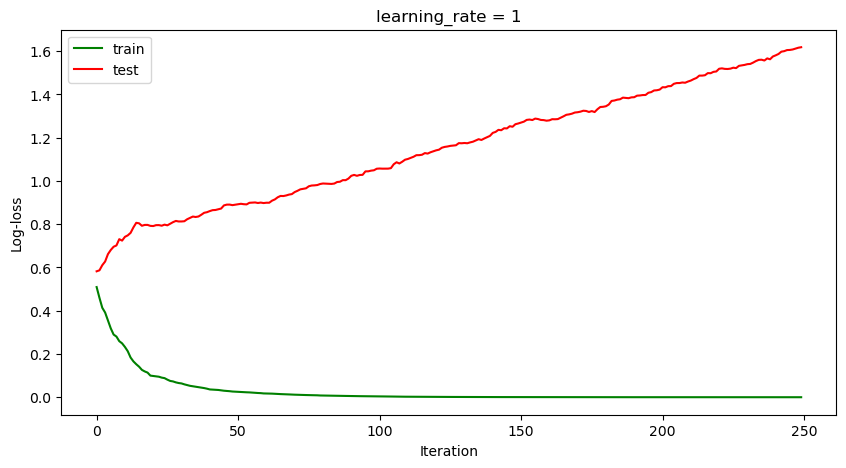

      Iter       Train Loss   Remaining Time 
         1           1.1255           15.23s
         2           1.0035           14.53s
         3           0.9386           14.52s
         4           0.8844           14.24s
         5           0.8381           13.90s
         6           0.7995           13.85s
         7           0.7559           13.59s
         8           0.7205           13.43s
         9           0.6958           13.45s
        10           0.6725           13.27s
        20           0.4672           12.69s
        30           0.3179           12.48s
        40           0.2274           11.81s
        50           0.1774           11.23s
        60           0.1394           10.85s
        70           0.1050           10.42s
        80           0.0805            9.82s
        90           0.0650            9.34s
       100           0.0511            8.84s
       200           0.0058            2.94s
Минимальный log-loss на test = 0.5585
Номер итерации: 

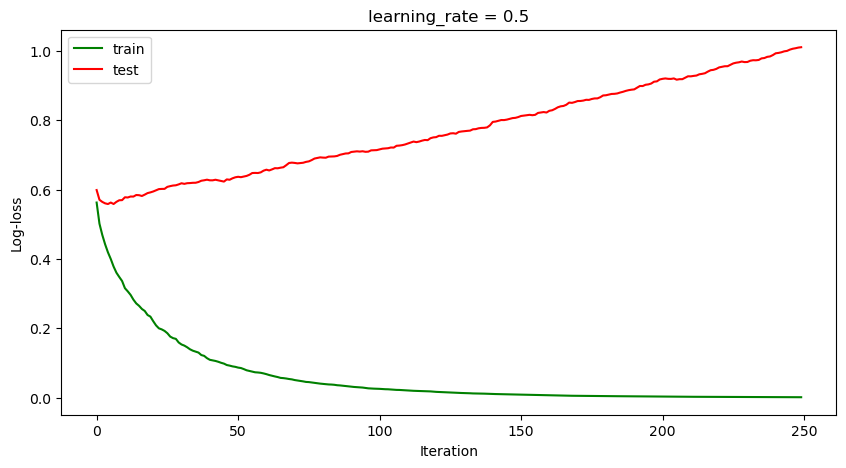

      Iter       Train Loss   Remaining Time 
         1           1.2095           20.07s
         2           1.1006           19.07s
         3           1.0240           17.95s
         4           0.9729           17.37s
         5           0.9387           16.93s
         6           0.8948           16.27s
         7           0.8621           16.00s
         8           0.8360           15.69s
         9           0.8171           15.50s
        10           0.7883           15.32s
        20           0.6164           15.60s
        30           0.4933           22.24s
        40           0.4248           24.55s
        50           0.3345           21.73s
        60           0.2760           19.58s
        70           0.2263           18.93s
        80           0.1971           17.14s
        90           0.1693           15.48s
       100           0.1388           14.47s
       200           0.0294            4.55s
Минимальный log-loss на test = 0.5426
Номер итерации: 

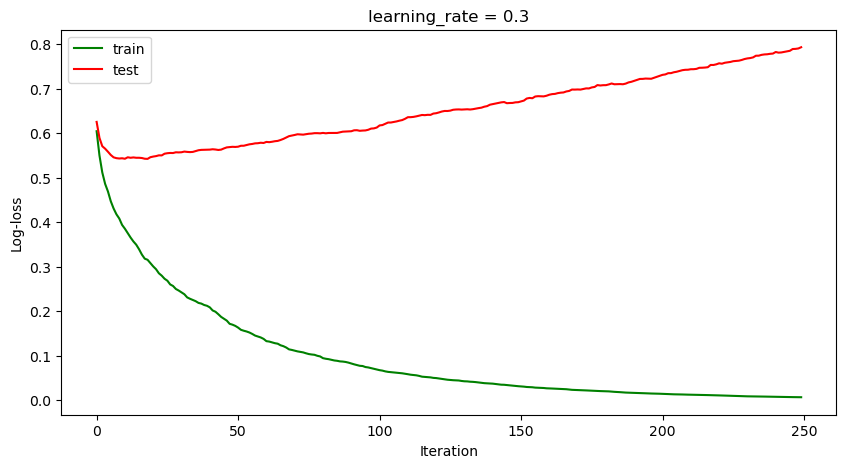

      Iter       Train Loss   Remaining Time 
         1           1.2613           14.04s
         2           1.1715           14.53s
         3           1.1009           14.66s
         4           1.0529           14.35s
         5           1.0130           14.53s
         6           0.9740           14.25s
         7           0.9475           13.98s
         8           0.9197           13.71s
         9           0.8979           13.71s
        10           0.8730           13.54s
        20           0.7207           12.85s
        30           0.6055           12.24s
        40           0.5244           11.68s
        50           0.4501           11.13s
        60           0.3908           10.51s
        70           0.3372            9.94s
        80           0.3009            9.39s
        90           0.2603            8.82s
       100           0.2327            8.24s
       200           0.0835            2.71s
Минимальный log-loss на test = 0.5305
Номер итерации: 

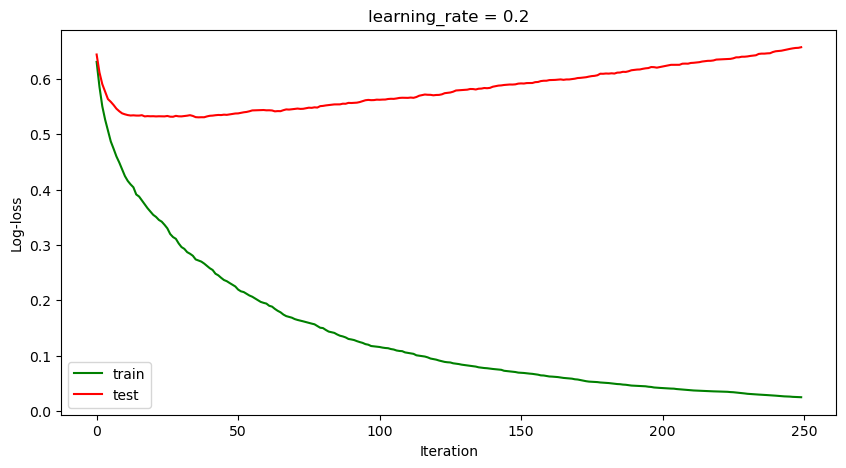

      Iter       Train Loss   Remaining Time 
         1           1.3199           14.92s
         2           1.2645           14.65s
         3           1.2170           13.99s
         4           1.1775           13.62s
         5           1.1404           13.76s
         6           1.1106           13.48s
         7           1.0844           13.38s
         8           1.0617           13.22s
         9           1.0411           13.05s
        10           1.0223           13.01s
        20           0.8864           12.84s
        30           0.7844           12.18s
        40           0.7176           11.52s
        50           0.6590           11.05s
        60           0.6120           10.46s
        70           0.5599            9.85s
        80           0.5242            9.30s
        90           0.4829            8.76s
       100           0.4473            8.28s
       200           0.2379            3.40s
Минимальный log-loss на test = 0.5261
Номер итерации: 

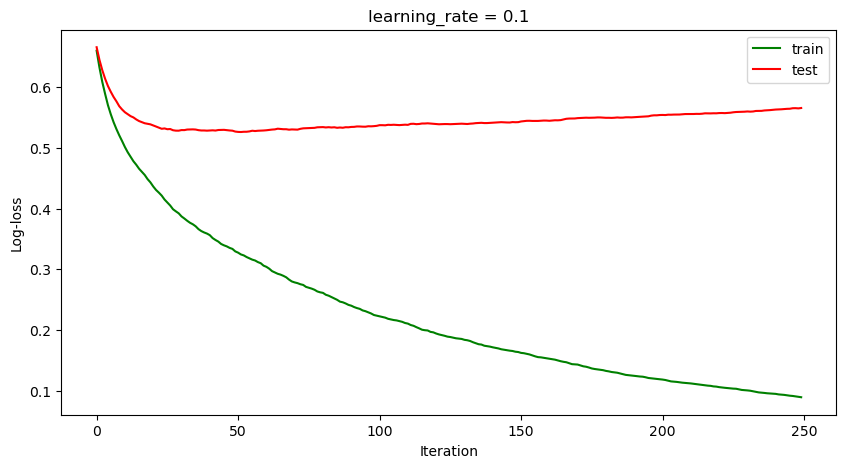

In [496]:
from matplotlib import pyplot as plt
import numpy as np
from sklearn.metrics import log_loss
from sklearn.ensemble import GradientBoostingClassifier

learning_rates = [1, 0.5, 0.3, 0.2, 0.1]
for lr in learning_rates:
    clf = GradientBoostingClassifier(
        n_estimators=250,
        verbose=True,
        random_state=241,
        learning_rate=lr
    )

    clf.fit(X_train, y_train)

    # Списки ошибок
    train_losses = []
    test_losses = []

    # Пробегаем по итерациям (staged_decision_function)
    for y_pred_train in clf.staged_decision_function(X_train):
        y_pred_train_prob = 1.0 / (1.0 + np.exp(-y_pred_train))
        train_losses.append(log_loss(y_train, y_pred_train_prob))

    for y_pred_test in clf.staged_decision_function(X_test):
        y_pred_test_prob = 1.0 / (1.0 + np.exp(-y_pred_test))
        test_losses.append(log_loss(y_test, y_pred_test_prob))

    # Находим минимальный log-loss
    min_test_loss = np.min(test_losses)
    best_iter = np.argmin(test_losses)

    print(f"Минимальный log-loss на test = {min_test_loss:.4f}")
    print(f"Номер итерации: {best_iter}")

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, "g-", label="train")
    plt.plot(test_losses, "r-", label="test")
    plt.title(f"learning_rate = {lr}")
    plt.xlabel("Iteration")
    plt.ylabel("Log-loss")
    plt.legend()
    plt.show()

3. Как можно охарактеризовать график качества на тестовой выборке, начиная с некоторой итерации: переобучение (overfitting) или
недообучение (underfitting)? В ответе укажите одно из слов overfitting
либо underfitting.

overfitting

4. Приведите минимальное значение log-loss на тестовой выборке и
номер итерации, на котором оно достигается, при learning_rate =
0.2.


Минимальный log-loss на test = 0.5305
Номер итерации: 36

5. На этих же данных обучите RandomForestClassifier с количеством
деревьев, равным количеству итераций, на котором достигается
наилучшее качество у градиентного бустинга из предыдущего пункта, random_state=241 и остальными параметрами по умолчанию.
Какое значение log-loss на тесте получается у этого случайного леса? (Не забывайте, что предсказания нужно получать с помощью
функции predict_proba. В данном случае брать сигмоиду от оценки
вероятности класса не нужно)

In [497]:
min_test_loss = np.min(test_losses)
best_iter = np.argmin(test_losses)
print(best_iter)

51


In [498]:
from sklearn.ensemble import RandomForestClassifier
rfc =  RandomForestClassifier(n_estimators=best_iter, random_state=241)
rfc.fit(X_train, y_train)
y_pred = rfc.predict_proba(X_test)
rf_logloss = log_loss(y_test, y_pred[:, 1])
print("Log-loss случайного леса:", rf_logloss)


Log-loss случайного леса: 0.5390618347947492


Обратите внимание, что, хотя в градиентного бустинге гораздо более слабые базовые алгоритмы, он выигрывает у случайного леса благодаря более "направленной"настройке — каждый следующий алгоритм
исправляет ошибки имеющейся композиции. Также он обучается быстрее случайного леса благодаря использованию неглубоких деревьев. В
то же время, случайный лес может показать более высокое качество при
неограниченных ресурсах — так, он выиграет у градиентного бустинга
на наших данных, если увеличить число деревьев до нескольких сотен
(проверьте сами!).
